# Модуль 4. Производные и оптимизация

Ноутбук к [модулю 4](https://drobyshevdev.github.io/lemma/modules/04-derivatives-and-optimisation/).

Семь сюжетов: численная производная, gradient check, спуск, длина шага, овраг, момент и SGD.

Здесь пишется код, который в модуле 8 станет обратным распространением. Ничего сложнее `numpy` не нужно.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RNG = np.random.default_rng(20260803)
np.set_printoptions(precision=5, suppress=True)

plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Численная производная и выбор шага

Производная — предел. Подставим вместо предела маленькое `h` и посмотрим, насколько маленьким его стоит брать.

In [2]:
def f(x):
    return np.sin(x) * np.exp(0.3 * x)

def f_prime(x):                                   # выведено руками
    return np.exp(0.3 * x) * (np.cos(x) + 0.3 * np.sin(x))

x0 = 1.3
exact = f_prime(x0)

print(f"аналитически: {exact:.10f}\n")
print(f"{'h':>10} {'односторонняя':>16} {'центральная':>16}")
for h in [1e-1, 1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12]:
    forward = (f(x0 + h) - f(x0)) / h
    central = (f(x0 + h) - f(x0 - h)) / (2 * h)
    print(f"{h:>10.0e} {abs(forward - exact):>16.2e} {abs(central - exact):>16.2e}")

аналитически: 0.8220377124

         h    односторонняя      центральная
     1e-01         5.54e-02         2.55e-03
     1e-02         5.32e-03         2.55e-05
     1e-04         5.29e-05         2.55e-09
     1e-06         5.29e-07         1.26e-10
     1e-08         3.00e-08         3.32e-09
     1e-10         1.94e-06         8.29e-07
     1e-12         2.86e-05         8.24e-05


Две ошибки тянут в разные стороны. Большое `h` — плохое приближение предела. Слишком маленькое `h` — вычитание почти равных чисел, и точность съедается округлением.

Оптимум посередине, и центральная разность заметно точнее односторонней при том же `h`. Поэтому в gradient check берут именно её и `h` около `1e-5`.

**Сломайте:** возьмите `h = 1e-16`. Что вернёт формула и почему?

## 2. Gradient check

Главный приём отладки обучения. Аналитический градиент, выведенный руками, сверяется с численным.

Проверяем формулу из текста: для логистической потери градиент равен $(p - y)\,x$.

In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def logistic_loss(w, X, y):
    p = np.clip(sigmoid(X @ w), 1e-12, 1 - 1e-12)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))

def logistic_grad(w, X, y):
    """Выведено цепным правилом: всё сократилось до (p - y) x."""
    p = sigmoid(X @ w)
    return X.T @ (p - y) / len(y)

def gradient_check(loss, grad, w, *args, h=1e-5):
    """Относительное расхождение аналитического градиента с численным.

    Меньше 1e-7 — формула верна. Больше 1e-4 — ошибка в выводе.
    """
    analytic = grad(w, *args)
    numeric = np.zeros_like(w)
    for i in range(len(w)):
        step = np.zeros_like(w)
        step[i] = h
        numeric[i] = (loss(w + step, *args) - loss(w - step, *args)) / (2 * h)
    denom = np.linalg.norm(analytic) + np.linalg.norm(numeric)
    return float(np.linalg.norm(analytic - numeric) / denom), analytic, numeric

rng = np.random.default_rng(2)
Xc = rng.normal(0, 1, size=(120, 4))
yc = (Xc @ np.array([1.0, -2.0, 0.5, 0.0]) + rng.normal(0, 0.5, 120) > 0).astype(float)
w0 = rng.normal(0, 0.3, 4)

rel, analytic, numeric = gradient_check(logistic_loss, logistic_grad, w0, Xc, yc)
print("аналитический:", analytic)
print("численный:    ", numeric)
print(f"\nотносительное расхождение: {rel:.2e}")

аналитический: [-0.13001  0.40318 -0.14506  0.02798]
численный:     [-0.13001  0.40318 -0.14506  0.02798]

относительное расхождение: 5.31e-12


Расхождение порядка `1e-10`. Формула верна.

Теперь испортим её нарочно — так выглядит опечатка в выводе.

In [4]:
def broken_grad(w, X, y):
    p = sigmoid(X @ w)
    return X.T @ (y - p) / len(y)          # знак перепутан

rel_broken, _, _ = gradient_check(logistic_loss, broken_grad, w0, Xc, yc)
print(f"расхождение при перепутанном знаке: {rel_broken:.2e}")
print("\nЕдиница вместо 1e-10. Такую ошибку gradient check ловит за секунду,")
print("а без него она выглядит как «модель почему-то не учится».")

расхождение при перепутанном знаке: 1.00e+00

Единица вместо 1e-10. Такую ошибку gradient check ловит за секунду,
а без него она выглядит как «модель почему-то не учится».


## 3. Спуск и длина шага

Простейшая задача с известным минимумом: $f(x) = x^2$, минимум в нуле. Смотрим, что делает шаг.

In [5]:
def descend_1d(eta, steps=25, x0=2.0):
    xs = [x0]
    for _ in range(steps):
        x = xs[-1]
        if not np.isfinite(x) or abs(x) > 1e12:
            break
        xs.append(x - eta * 2 * x)          # производная x^2 равна 2x
    return np.array(xs)

for eta in [0.05, 0.4, 0.9, 1.0, 1.05]:
    xs = descend_1d(eta)
    end = xs[-1]
    if abs(end) < 1e-3:
        verdict = "сходится"
    elif abs(end) > 10:
        verdict = "расходится"
    elif abs(abs(end) - abs(xs[0])) < 1e-9:
        verdict = "колеблется, не сходится никогда"
    else:
        verdict = "ползёт"
    print(f"eta = {eta:<5} после 25 шагов x = {end:>14.4g}   {verdict}")

eta = 0.05  после 25 шагов x =         0.1436   ползёт
eta = 0.4   после 25 шагов x =      6.711e-18   сходится
eta = 0.9   после 25 шагов x =      -0.007556   ползёт
eta = 1.0   после 25 шагов x =             -2   колеблется, не сходится никогда
eta = 1.05  после 25 шагов x =         -21.67   расходится


Граница ровно на `eta = 1.0`: шаг $x \to x - 2\eta x = (1 - 2\eta)x$, и последовательность сходится, пока $|1 - 2\eta| < 1$, то есть при $\eta < 1$. При `eta = 1.0` точка вечно скачет между $2$ и $-2$, при большем — улетает.

Это не эвристика, а точная граница. Для настоящих задач её не вычислить, но природа явления та же.

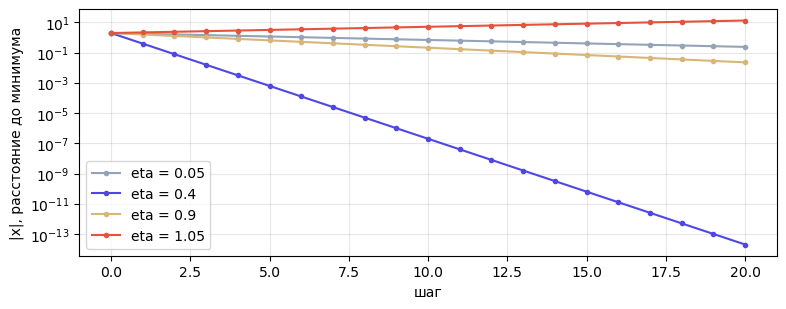

In [6]:
fig, ax = plt.subplots()
for eta, colour in [(0.05, "#94a3b8"), (0.4, "#4f46e5"), (0.9, "#d8b678"), (1.05, "#e5533c")]:
    xs = descend_1d(eta, steps=20)
    ax.plot(np.abs(xs), marker="o", ms=3, color=colour, label=f"eta = {eta}")
ax.set_yscale("log")
ax.set_xlabel("шаг")
ax.set_ylabel("|x|, расстояние до минимума")
ax.legend()
plt.show()

## 4. Овраг

Двумерная квадратичная функция, у которой одна ось в 50 раз круче другой. Число обусловленности из модуля 3 здесь равно 50.

In [7]:
CURVATURE = np.array([50.0, 1.0])       # kappa = 50

def loss2d(p):
    return 0.5 * float(CURVATURE @ (p ** 2))

def grad2d(p):
    return CURVATURE * p

def run(eta, momentum=0.0, steps=400, start=(1.0, 1.0)):
    p = np.array(start, dtype=float)
    v = np.zeros(2)
    path = [p.copy()]
    for _ in range(steps):
        v = momentum * v + grad2d(p)
        p = p - eta * v
        path.append(p.copy())
        if not np.all(np.isfinite(p)):
            break
    return np.array(path)

def steps_to_reach(path, tol=1e-3):
    dist = np.linalg.norm(path, axis=1)
    reached = np.where(dist < tol)[0]
    return int(reached[0]) if len(reached) else None

ETA = 0.035                              # близко к максимальному устойчивому 2/50
plain = run(ETA)
with_momentum = run(ETA, momentum=0.85)

print(f"без момента:  {steps_to_reach(plain)} шагов до 1e-3")
print(f"с моментом:   {steps_to_reach(with_momentum)} шагов до 1e-3")

без момента:  194 шагов до 1e-3
с моментом:   81 шагов до 1e-3


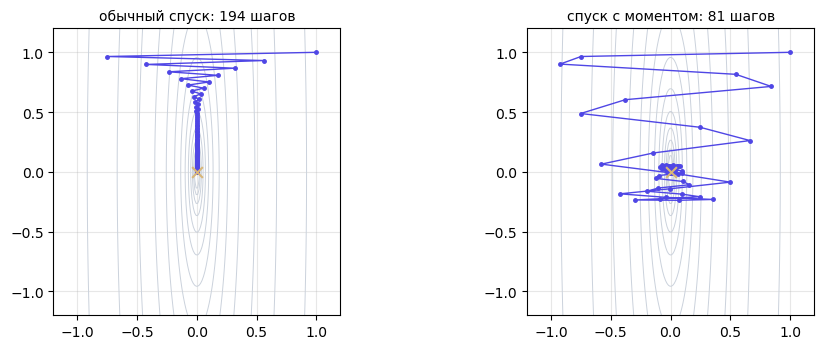

In [8]:
gx, gy = np.meshgrid(np.linspace(-1.2, 1.2, 200), np.linspace(-1.2, 1.2, 200))
levels = 0.5 * (CURVATURE[0] * gx ** 2 + CURVATURE[1] * gy ** 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, path, title in [(ax1, plain, "обычный спуск"),
                        (ax2, with_momentum, "спуск с моментом")]:
    ax.contour(gx, gy, levels, levels=np.logspace(-2, 1.6, 14), colors="#cbd2dc", linewidths=0.7)
    ax.plot(path[:, 0], path[:, 1], marker="o", ms=2.5, lw=1, color="#4f46e5")
    ax.scatter([0], [0], marker="x", s=60, color="#d8b678", zorder=5)
    ax.set_title(f"{title}: {steps_to_reach(path)} шагов", fontsize=10)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

Слева зигзаг: градиент на склоне показывает поперёк оврага, и спуск бьётся от стенки к стенке. Справа колебания поперёк гасят друг друга, а движение вдоль дна накапливается.

Теперь второе лечение из текста — нормализация. Она не меняет метод, она меняет задачу: делает овраг круглым.

In [9]:
print(f"{'kappa':>8} {'шагов без момента':>20} {'шагов с моментом':>19}")
for kappa in [1.0, 5.0, 20.0, 50.0, 200.0]:
    CURVATURE = np.array([kappa, 1.0])
    eta = 1.8 / kappa                    # почти максимальный устойчивый шаг
    a = steps_to_reach(run(eta, steps=4000))
    b = steps_to_reach(run(eta, momentum=0.9, steps=4000))
    print(f"{kappa:>8.0f} {str(a):>20} {str(b):>19}")

CURVATURE = np.array([50.0, 1.0])        # вернуть как было

   kappa    шагов без момента    шагов с моментом
       1                   33                  73
       5                   31                 127
      20                   74                 127


      50                  189                 125
     200                  765                 102


Читайте таблицу по столбцам, а не по строкам.

**Без момента** число шагов растёт примерно линейно по `kappa`: 33, 31, 74, 189, 765. При `kappa = 1` — круглая чаша, спуск приходит почти сразу. Вот зачем масштабируют признаки: это уменьшение `kappa`, то есть прямое сокращение числа шагов. Не гигиена, а арифметика.

**С моментом** число шагов почти не зависит от `kappa` — держится около сотни везде. Но посмотрите на первые две строки: при `kappa` 1 и 5 момент оказался **вдвое и вчетверо хуже** обычного спуска.

Это не ошибка в коде. Момент накапливает инерцию, и на круглой чаше ему нечего гасить: он проскакивает минимум и возвращается. Выигрыш появляется там, где есть что гасить, и растёт вместе с `kappa`: при 200 это 765 шагов против 102, то есть в семь с половиной раз.

Отсюда правило, которое дороже самой формулы момента: **приём, полезный на трудной задаче, не обязан быть полезным на лёгкой.** Разгон, который спасает в овраге, мешает в чаше. Так же будет с половиной приёмов дальше в курсе, и проверять их надо на своей задаче, а не брать по умолчанию.

**Сломайте:** поставьте `momentum = 0.99`. Всегда ли больше — лучше? И найдите, при каком `kappa` момент начинает выигрывать.

## 5. SGD против полного спуска

Настоящая регрессия, два способа считать градиент: по всем данным и по случайному батчу.

In [10]:
rng = np.random.default_rng(9)
N, D = 4000, 8
Xr = rng.normal(0, 1, size=(N, D))
true_w = rng.normal(0, 1, D)
yr = Xr @ true_w + rng.normal(0, 0.4, N)

def mse(w):
    return float(np.mean((Xr @ w - yr) ** 2))

def train(batch_size, eta=0.05, epochs=30, seed=0):
    """batch_size=None означает полный градиент по всем данным."""
    rng = np.random.default_rng(seed)
    w = np.zeros(D)
    history, gradients = [mse(w)], 0
    for _ in range(epochs):
        if batch_size is None:
            g = 2 * Xr.T @ (Xr @ w - yr) / N
            w -= eta * g
            gradients += N
        else:
            order = rng.permutation(N)
            for start in range(0, N, batch_size):
                idx = order[start:start + batch_size]
                g = 2 * Xr[idx].T @ (Xr[idx] @ w - yr[idx]) / len(idx)
                w -= eta * g
                gradients += len(idx)
        history.append(mse(w))
    return np.array(history), w, gradients

for name, bs in [("полный градиент", None), ("батч 256", 256), ("батч 32", 32)]:
    hist, w, seen = train(bs)
    print(f"{name:<18} итоговый MSE {hist[-1]:.4f}   "
          f"ошибка весов {np.linalg.norm(w - true_w):.4f}")

полный градиент    итоговый MSE 0.1796   ошибка весов 0.1555
батч 256           итоговый MSE 0.1589   ошибка весов 0.0259
батч 32            итоговый MSE 0.1604   ошибка весов 0.0513


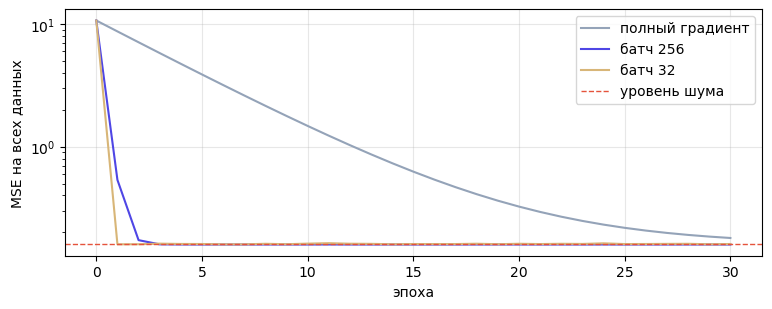

In [11]:
fig, ax = plt.subplots()
for (name, bs), colour in zip([("полный градиент", None), ("батч 256", 256), ("батч 32", 32)],
                              ["#94a3b8", "#4f46e5", "#d8b678"]):
    hist, _, _ = train(bs)
    ax.plot(hist, label=name, color=colour)
ax.axhline(0.4 ** 2, color="#e5533c", ls="--", lw=1, label="уровень шума")
ax.set_yscale("log")
ax.set_xlabel("эпоха")
ax.set_ylabel("MSE на всех данных")
ax.legend()
plt.show()

За то же число проходов по данным SGD уходит гораздо дальше: он делает много дешёвых шагов вместо одного дорогого. Кривая при этом менее гладкая — это и есть шум оценки градиента.

Красная линия — дисперсия шума в данных. Ниже неё MSE не опустится: этот шум непредсказуем по определению, как и в модуле 2.

**Сломайте:** поставьте батч в 1 объект. Станет ли лучше? И попробуйте `eta = 0.3` для батча 32 — при каком размере батча большой шаг перестаёт быть допустимым?

## Итог

Часть I закончена. Что посчитано своими руками:

1. У численной производной есть оптимальное `h`: слишком большое — плохое приближение, слишком маленькое — округление. Центральная разность точнее односторонней на четыре порядка.
2. Gradient check ловит перепутанный знак мгновенно: расхождение `1e-12` против единицы.
3. У шага есть точная граница устойчивости. За ней спуск расходится, а на самой границе колеблется вечно — и то и другое выглядит как «модель не учится», хотя это арифметика.
4. Число шагов растёт линейно по числу обусловленности: от 33 при `kappa = 1` до 765 при 200.
5. Момент убирает эту зависимость, но на хорошо обусловленной задаче он **вредит**. Приём, полезный на трудной задаче, не обязан быть полезным на лёгкой.
6. SGD за то же число проходов по данным уходит дальше полного градиента, платя гладкостью кривой.

Дальше — [часть II](https://drobyshevdev.github.io/lemma/programme/): первые настоящие модели, они же базовые линии для всего остального курса.